In [ ]:
!pip install pandas numpy scikit-learn matplotlib joblib

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import joblib

In [22]:
df = pd.read_csv(r".\data\online_retail.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [24]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [25]:
df = df.dropna(subset=["InvoiceDate", "Quantity", "UnitPrice"])

In [26]:
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

In [27]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [28]:
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["Revenue"]
    .sum()
    .reset_index()
)

daily_sales.columns = ["date", "daily_sales"]

daily_sales["date"] = pd.to_datetime(daily_sales["date"])

daily_sales.head()

,date,daily_sales
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46


In [36]:
daily_sales["day_of_week"] = daily_sales["date"].dt.dayofweek
daily_sales["day"] = daily_sales["date"].dt.day
daily_sales["month"] = daily_sales["date"].dt.month
daily_sales["is_weekend"] = (
    daily_sales["day_of_week"] >= 5
).astype(int)

In [37]:
daily_sales["lag_1"] = daily_sales["daily_sales"].shift(1)

daily_sales["lag_7"] = daily_sales["daily_sales"].shift(7)

daily_sales["lag_14"] = daily_sales["daily_sales"].shift(14)

daily_sales["lag_28"] = daily_sales["daily_sales"].shift(28)

In [38]:
daily_sales["rolling_mean_7"] = (
    daily_sales["daily_sales"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

daily_sales["rolling_mean_14"] = (
    daily_sales["daily_sales"]
    .shift(1)
    .rolling(window=14)
    .mean()
)

daily_sales["rolling_std_7"] = (
    daily_sales["daily_sales"]
    .shift(1)
    .rolling(window=7)
    .std()
)

In [39]:
daily_sales = daily_sales.dropna()

daily_sales.head()

,date,daily_sales,day_of_week,day,month,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7
28,2011-01-13,20624.64,3,13,1,0,24693.78,32634.47,45418.33,58960.79,33650.078571,28349.940714,17209.499406
29,2011-01-14,47576.90,4,14,1,0,20624.64,40382.85,7534.91,47748.38,31934.388571,26578.962857,17911.945097
30,2011-01-16,7242.06,6,16,1,1,47576.90,28836.59,26789.13,46943.71,32962.110000,29439.105000,18667.908501
31,2011-01-17,29333.02,0,17,1,0,7242.06,15778.20,47304.09,31774.95,29877.177143,28042.885714,21090.393660
32,2011-01-18,95978.05,1,18,1,0,29333.02,24569.07,6199.97,54830.46,31813.580000,26759.237857,20182.895344


In [40]:
daily_sales = daily_sales.dropna()

daily_sales.head()

,date,daily_sales,day_of_week,day,month,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_std_7
28,2011-01-13,20624.64,3,13,1,0,24693.78,32634.47,45418.33,58960.79,33650.078571,28349.940714,17209.499406
29,2011-01-14,47576.90,4,14,1,0,20624.64,40382.85,7534.91,47748.38,31934.388571,26578.962857,17911.945097
30,2011-01-16,7242.06,6,16,1,1,47576.90,28836.59,26789.13,46943.71,32962.110000,29439.105000,18667.908501
31,2011-01-17,29333.02,0,17,1,0,7242.06,15778.20,47304.09,31774.95,29877.177143,28042.885714,21090.393660
32,2011-01-18,95978.05,1,18,1,0,29333.02,24569.07,6199.97,54830.46,31813.580000,26759.237857,20182.895344


In [41]:
daily_sales.to_csv(
    "./data/daily_sales_features.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [42]:
features = [
    "day_of_week",
    "day",
    "month",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7"
]

X = daily_sales[features]

y = daily_sales["daily_sales"]

In [43]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [45]:
model = Ridge(alpha=1.0)

model.fit(
    X_train_scaled,
    y_train
)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [46]:
y_pred = model.predict(X_test_scaled)

In [47]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Ridge Regression Performance")
print("-----------------------------")

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Ridge Regression Performance
-----------------------------
MAE  : 13,669.41
RMSE : 24,731.60
R²   : 0.1706


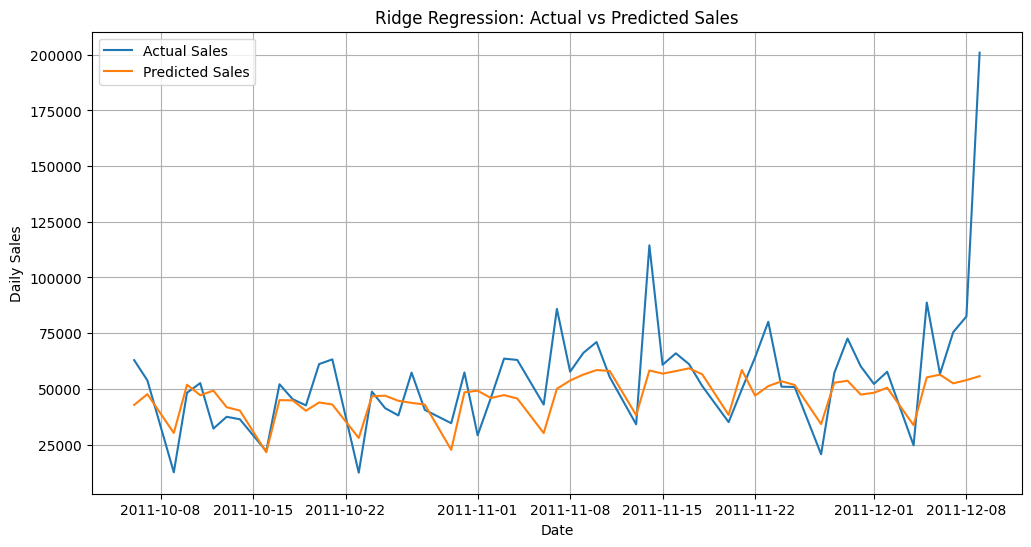

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_sales["date"].iloc[split_index:],
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    daily_sales["date"].iloc[split_index:],
    y_pred,
    label="Predicted Sales"
)

plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.title("Ridge Regression: Actual vs Predicted Sales")

plt.legend()
plt.grid(True)

plt.show()

In [49]:
joblib.dump(
    model,
    "./models/ridge_sales_model.pkl"
)

joblib.dump(
    scaler,
    "./models/ridge_scaler.pkl"
)

print("Model saved successfully!")

Model saved successfully!
